In [0]:
storage_account_name = "lake60305015"
storage_account_key = "PRIVATE"
spark.conf.set(
 f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
 storage_account_key
)

In [0]:
gold_path = "abfss://curated@lake60305015.dfs.core.windows.net/features_v1/"
gold_df = spark.read.parquet(gold_path)
gold_df.printSchema()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



/home/spark-baebccb2-0dd7-4d32-921a-64/.ipykernel/2433/command-4674432834723793-3459971905:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="overall", y="count", data=rating_counts, palette="viridis")


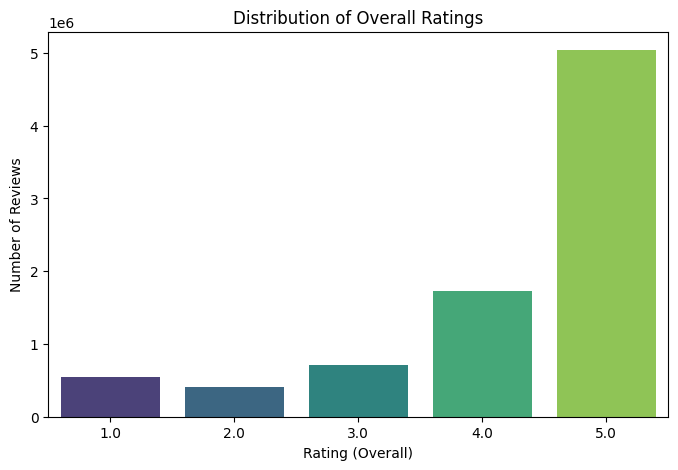

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = gold_df.groupBy("overall").count().orderBy("overall").toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(x="overall", y="count", data=rating_counts, palette="viridis")
plt.title("Distribution of Overall Ratings")
plt.xlabel("Rating (Overall)")
plt.ylabel("Number of Reviews")
plt.show()

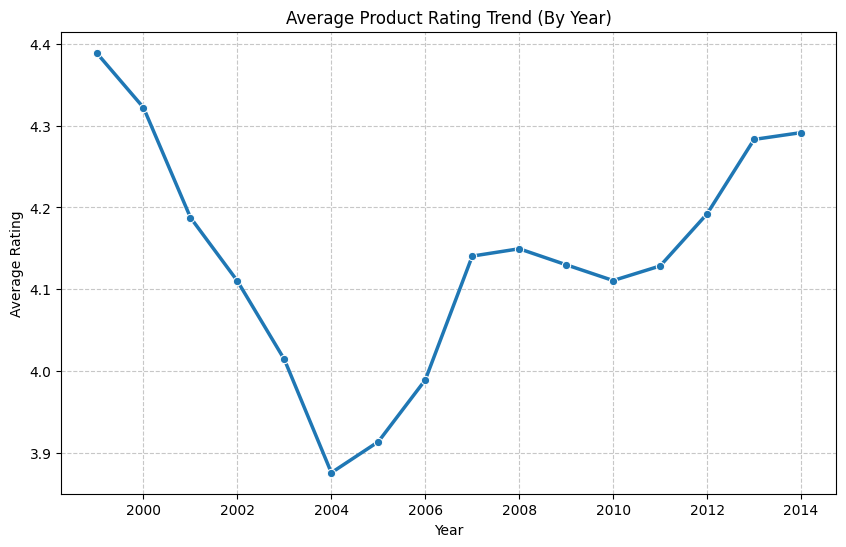

In [0]:
# average rating per year
yearly_avg = gold_df.groupBy("review_year").avg("overall").orderBy("review_year").toPandas()

plt.figure(figsize=(10, 6))
sns.lineplot(x="review_year", y="avg(overall)", data=yearly_avg, marker="o", linewidth=2.5)
plt.title("Average Product Rating Trend (By Year)")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/home/spark-baebccb2-0dd7-4d32-921a-64/.ipykernel/2433/command-5589343313630677-2100629397:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="overall", y="count", data=rating_counts, palette="viridis")


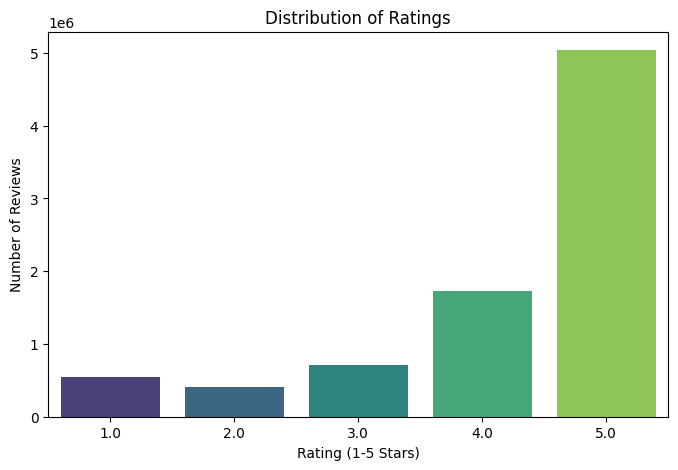

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import length

# We aggregate the overall column to count how many of each rating exist
rating_counts = gold_df.groupBy("overall").count().orderBy("overall").toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(x="overall", y="count", data=rating_counts, palette="viridis")
plt.title("Distribution of Ratings")
plt.xlabel("Rating (1-5 Stars)")
plt.ylabel("Number of Reviews")
plt.show()

Text(0, 0.5, 'Frequency')

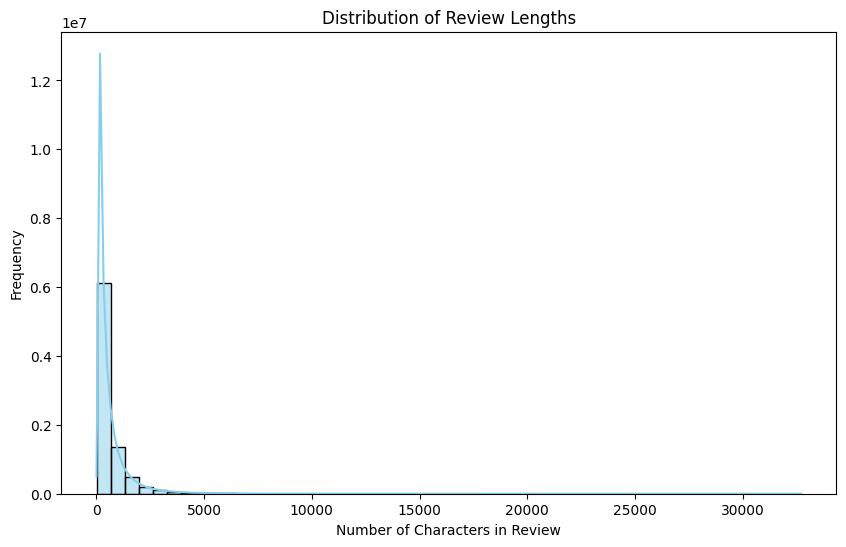

In [0]:
# 1. Calculate the length of the reviewText string
# 2. Select only that column and convert to pandas for plotting


review_lengths = gold_df.select(length("reviewText").alias("review_length")).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(review_lengths["review_length"], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters in Review")
plt.ylabel("Frequency")

In [0]:
sample_n = 300_000
sample_seed = 42
df_sampled = gold_df.orderBy("reviewerID").limit(sample_n)
print("Sampled rows:", df_sampled.count())

Sampled rows: 300000


In [0]:
total_count = gold_df.count()
fraction = 300000 / total_count

years = [row['review_year'] for row in gold_df.select("review_year").distinct().collect()]
fractions = {year: fraction for year in years}

df_sampled = gold_df.stat.sampleBy("review_year", fractions, seed=42)

print(f"Total Rows: {total_count}")
print(f"Sampled Rows: {df_sampled.count()}")

df_sampled.groupBy("review_year").count().orderBy("review_year").show()

Total Rows: 8437135
Sampled Rows: 299894
+-----------+------+
|review_year| count|
+-----------+------+
|       1999|    14|
|       2000|   135|
|       2001|   294|
|       2002|   394|
|       2003|   638|
|       2004|   858|
|       2005|  1678|
|       2006|  2734|
|       2007|  6301|
|       2008|  9009|
|       2009| 12320|
|       2010| 18260|
|       2011| 30784|
|       2012| 50227|
|       2013|105522|
|       2014| 60726|
+-----------+------+



In [0]:
# Check schema matches original
df_sampled.printSchema()
# Compare rating distribution with original dataset
gold_df.groupBy("overall").count().orderBy("overall").show()
df_sampled.groupBy("overall").count().orderBy("overall").show()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)

+-------+-------+
|overall|  count|
+-------+-------+
|    1.0| 543060|
|    2.0| 410280|
|    3.0| 710530|
|    4.0|1733465|
|    5.0|5039800|
+-------+-------+

+-------+------+
|overall| count|
+-------+------+
|    1.0| 19395|
|    2.0| 14459|
|    3.0| 25279|
|    4.0| 61389|
|    5.0|179372|
+-------+------+



In [0]:
sampled_gold_path = (
f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
"features_v1_sampled/"
)
df_sampled.write \
.mode("overwrite") \
.parquet(sampled_gold_path)